# Neuron optimization

In [1]:
import matplotlib.pyplot as plt
import optax
from tqdm import trange
from eleanor.models import FeLIF
import equinox as eqx
import jax.numpy as jnp
import jax
from spyx.axn import arctan

In [2]:
class Network(eqx.Module):
    linear: eqx.nn.Linear
    felif: FeLIF

    def __init__(self, *, key):
        linear = eqx.nn.Linear(1, 1, use_bias=False, key=key)
        self.felif = FeLIF(
            1,
            dt=1e-3,
            A=25e-12,
            I_dsc=3.2532312693054174e-11,
            V_thr=1.698682296181096,
            P_s=0.13321217250476625,
            spike_fn=arctan(),
            paramsScale=1e12,
        )
        new_weight = jnp.asarray([[0.3]])
        self.linear = eqx.tree_at(lambda x: x.weight, linear, new_weight)

    @jax.named_scope("nn.Network")
    def __call__(self, input_):
        x1 = jax.vmap(self.linear)(input_)
        s, c, v, p = self.felif(1000 * x1)

        return s, c, v, p

In [3]:
@eqx.filter_jit
def predict(model, input_):
    spikes, charge, V, P = model(input_)

    return spikes, charge, V, P


@eqx.filter_jit
def loss(model, input_, target):
    preds, _, _, _ = predict(model, input_)
    preds = jnp.sum(preds, axis=0)  # Sum over time
    return jnp.mean((preds - target) ** 2)

In [4]:
model = Network(key=jax.random.key(0))
opt = optax.sgd(learning_rate=1e-3)
opt_state = opt.init(model)

In [5]:
# Input every 5ms
input_ = jnp.array([[0], [0], [0], [0], [0], [0], [0], [0], [0], [1.0]] * 10)
target = jnp.array([1.0])

In [6]:
print("Optimizing")
loss_rec = []
param_rec = []
state = [model, opt_state]
nb_epochs = 15
for _ in trange(nb_epochs):
    grad_params, opt_state = state

    loss_val, grads = eqx.filter_value_and_grad(loss)(grad_params, input_, target)
    updates, opt_state = opt.update(grads, opt_state, grad_params)
    loss_rec.append(loss_val)

    new_param = eqx.apply_updates(grad_params, updates)
    state = [new_param, opt_state]
    param_rec.append(new_param.linear.weight[0, 0])
loss_rec = jnp.stack(loss_rec)
param_rec = jnp.stack(param_rec)

Optimizing


100%|██████████| 15/15 [00:05<00:00,  2.59it/s]


In [7]:
print("Predict")
_, preds_before, _, _ = predict(model, input_)
_, preds, V, P = predict(state[0], input_)
print("Finish")

Predict
Finish


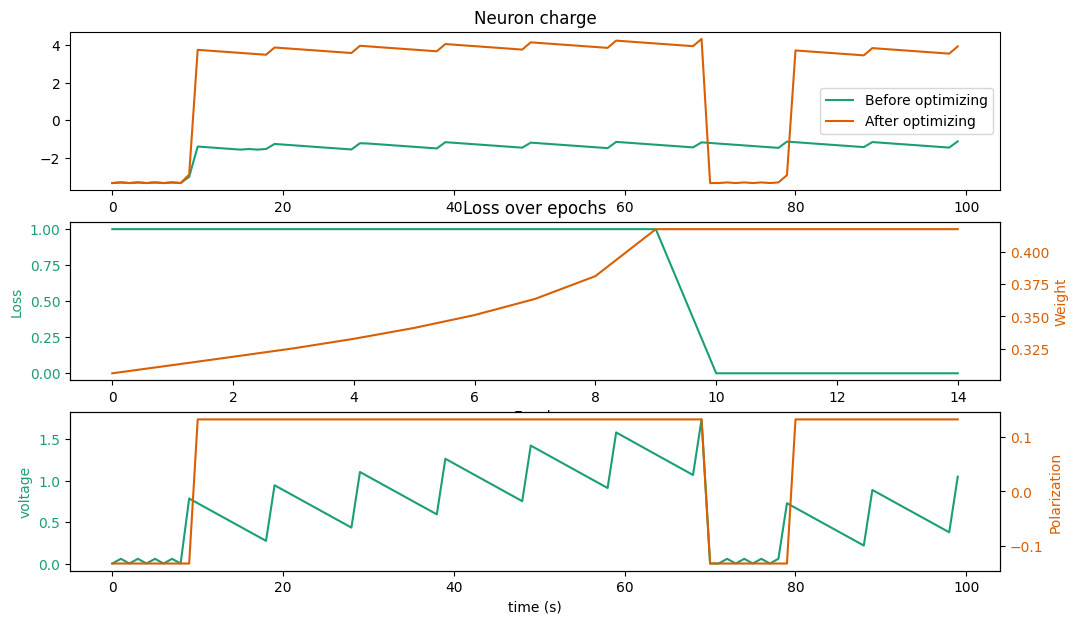

In [8]:
plt.figure(figsize=(12, 7))
plt.subplot(3, 1, 1)
plt.title("Neuron charge")
plt.plot(preds_before, c="#1b9e77", label="Before optimizing")
plt.plot(preds, c="#d95f02", label="After optimizing")
plt.legend()

ax1 = plt.subplot(3, 1, 2)
plt.title("Loss over epochs")

color = "#1b9e77"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color)
ax1.plot(loss_rec, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Weight", color=color)
ax2.plot(param_rec, color=color)
ax2.tick_params(axis="y", labelcolor=color)

ax1 = plt.subplot(3, 1, 3)

color = "#1b9e77"
ax1.set_xlabel("time (s)")
ax1.set_ylabel("voltage", color=color)
ax1.plot(V, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Polarization", color=color)
ax2.plot(P, color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.show()